In [1]:
#IMPORTS
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
os.makedirs("plots", exist_ok=True)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
)

import xgboost as xgb
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Bidirectional,
    GRU
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

In [2]:
# Upload Trainset.xlsx and Testset.xlsx (Colab only)
try:
    from google.colab import files
    print("Running in Google Colab — please upload Trainset.xlsx and Testset.xlsx:")
    files.upload()
except ImportError:
    print("Not running in Colab — skipping upload. "
          "Make sure Trainset.xlsx and Testset.xlsx are in the working directory.")

Not running in Colab — skipping upload. Make sure Trainset.xlsx and Testset.xlsx are in the working directory.


In [ ]:
#1.  LOAD DATA
train_data = pd.read_excel('Trainset.xlsx')
test_data  = pd.read_excel('Testset.xlsx')

print(f"Train : {train_data.shape}  |  Test : {test_data.shape}")
print(train_data.head())

Train : (1259, 7)  |  Test : (125, 7)
        Date        Open        High         Low       Close   Adj Close  \
0 2013-01-02  357.385559  361.151062  355.959839  359.288177  359.288177   
1 2013-01-03  360.122742  363.600128  358.031342  359.496826  359.496826   
2 2013-01-04  362.313507  368.339294  361.488861  366.600616  366.600616   
3 2013-01-07  365.348755  367.301056  362.929504  365.001007  365.001007   
4 2013-01-08  365.393463  365.771027  359.874359  364.280701  364.280701   

    Volume  
0  5115500  
1  4666500  
2  5562800  
3  3332900  
4  3373900  


In [3]:
#2.  TECHNICAL INDICATORS
# Record lengths before combining
train_len    = len(train_data)
combined_len = train_len + len(test_data)

# Combine into one continuous series so indicators
# at the start of test_data use train_data history
combined = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

# RSI
delta    = combined['Close'].diff()
gain     = delta.where(delta > 0, 0)
loss     = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
combined['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema12 = combined['Close'].ewm(span=12, adjust=False).mean()
ema26 = combined['Close'].ewm(span=26, adjust=False).mean()
combined['MACD']        = ema12 - ema26
combined['MACD_Signal'] = combined['MACD'].ewm(span=9, adjust=False).mean()

# Bollinger Bands
rolling_mean        = combined['Close'].rolling(20).mean()
rolling_std         = combined['Close'].rolling(20).std()
combined['BB_Upper'] = rolling_mean + 2 * rolling_std
combined['BB_Lower'] = rolling_mean - 2 * rolling_std

# dropna only removes rows from the very start (train side)
combined.dropna(inplace=True)
combined.reset_index(drop=True, inplace=True)

# Recalculate train boundary after dropped NaN rows
rows_dropped = combined_len - len(combined)
new_train_len = train_len - rows_dropped

# Split back
train_data = combined.iloc[:new_train_len].reset_index(drop=True)
test_data  = combined.iloc[new_train_len:].reset_index(drop=True)

In [4]:
#3.  FEATURES & CONSTANTS
FEATURES     = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower']
TARGET_COL = FEATURES.index('Close')
SEQ_LEN      = 60            # look-back window
N_FEAT       = len(FEATURES)

NN_FEATURES = ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal']
nn_indices  = [FEATURES.index(f) for f in NN_FEATURES]
N_FEAT_NN   = len(NN_FEATURES)

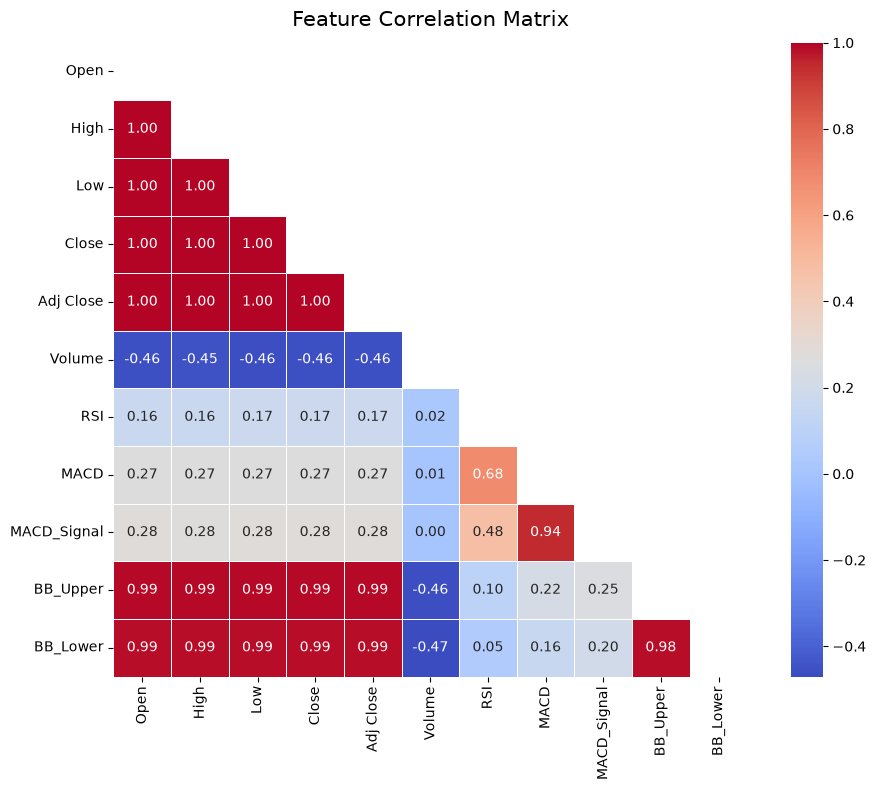

In [5]:
#4.  EDA — CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
corr = train_data[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, square=True, linewidths=0.5, annot_kws={'size': 10}
)
plt.title('Feature Correlation Matrix', fontsize=15, pad=12)
plt.tight_layout()
plt.savefig("plots/01_correlation_heatmap_eda.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# 5.  TRAIN–VALIDATION SPLIT (RAW DATA)
split_idx = int(0.8 * len(train_data))

train_df = train_data.iloc[:split_idx]
val_df   = train_data.iloc[split_idx:]

print(f"Train rows : {train_df.shape}")
print(f"Val rows   : {val_df.shape}")

Train rows : (992, 12)
Val rows   : (248, 12)


In [7]:
#6.  NORMALIZATION
scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit(train_df[FEATURES].values)

train_scaled = scaler.transform(train_df[FEATURES].values)

In [ ]:
# 7.  SEQUENCE BUILDER
def build_sequences(data, seq_len):
    """
    Create sliding windows of length seq_len.
    Target = Close price (TARGET_COL).
    """
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i])
        y.append(data[i, TARGET_COL])
    return np.array(X), np.array(y)

def build_return_targets(raw_close_prices, seq_len):
    """
    Target = % change in Close from day (i-1) to day i,
    using UNSCALED close prices. Used only for tree models
    (XGBoost, Random Forest) to avoid extrapolation issues.
    """
    returns = []
    for i in range(seq_len, len(raw_close_prices)):
        prev_close = raw_close_prices[i - 1]
        curr_close = raw_close_prices[i]
        returns.append((curr_close - prev_close) / prev_close)
    return np.array(returns)

# Training sequences
X_train, y_train = build_sequences(train_scaled, SEQ_LEN)

# Reduced-feature view of X_train, used only by BiLSTM/GRU
X_train_nn = X_train[:, :, nn_indices]

# Return-based targets for tree models (raw, unscaled Close prices)
y_train_ret = build_return_targets(train_df['Close'].values, SEQ_LEN)

# Validation sequences
# Need previous SEQ_LEN days
# from training set
val_inputs = pd.concat(
    (
        train_df[FEATURES].tail(SEQ_LEN),
        val_df[FEATURES]
    ),
    axis=0
)

val_scaled_full = scaler.transform(val_inputs.values)

X_val, y_val = build_sequences(
    val_scaled_full,
    SEQ_LEN
)

# Reduced-feature view of X_val, used only by BiLSTM/GRU
X_val_nn = X_val[:, :, nn_indices]

# Return-based validation target — now val_inputs exists, safe to call
y_val_ret = build_return_targets(val_inputs['Close'].values, SEQ_LEN)

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape} | y_val   : {y_val.shape}")
print(f"y_train_ret : {y_train_ret.shape} | y_val_ret : {y_val_ret.shape}")
print(f"X_train_nn : {X_train_nn.shape} | X_val_nn : {X_val_nn.shape}")

X_train : (932, 60, 11) | y_train : (932,)
X_val   : (248, 60, 11) | y_val   : (248,)
y_train_ret : (932,) | y_val_ret : (248,)
X_train_nn : (932, 60, 5) | X_val_nn : (248, 60, 5)


In [9]:
#8.  HELPERS
def early_stop():
    """Return a fresh EarlyStopping instance for each model."""
    return EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    )
def checkpoint(filename):
    return ModelCheckpoint(
        filename,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
def reduce_lr():
    return ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )

def inverse_price(scaled_preds):
    dummy = np.zeros((len(scaled_preds), N_FEAT))
    dummy[:, TARGET_COL] = scaled_preds
    return scaler.inverse_transform(dummy)[:, TARGET_COL]

def predict_prices(model, X, flatten_output=True):
    raw = model.predict(X)
    if flatten_output:
        raw = raw.flatten()
    return inverse_price(raw)

def reconstruct_from_returns(pred_returns, prev_closes):
    """prev_closes[i] = actual close price the day before prediction i"""
    return prev_closes * (1 + pred_returns)

def directional_accuracy(real, pred):
    real_dir = np.diff(real) > 0
    pred_dir = np.diff(pred) > 0
    return np.mean(real_dir == pred_dir) * 100

MODEL_COLORS = {
    'BiLSTM':   'royalblue',
    'GRU':      'seagreen',
    'XGBoost':  'crimson',
    'Linear Regression': 'purple',
    'Random Forest': 'brown',
    'Ensemble': 'gold'
}

In [10]:
#9.  BI-LSTM
print("\n" + "="*50)
print("  Training  :  Bidirectional LSTM")
print("="*50)

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(SEQ_LEN, N_FEAT_NN)),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(1)
], name='BiLSTM')
model_bilstm.compile(optimizer='adam', loss='mse')
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_nn, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_nn, y_val),
    callbacks=[early_stop(), checkpoint("best_bilstm.keras"), reduce_lr()],
    verbose=1
)


  Training  :  Bidirectional LSTM


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,601 (912.50 KB)

 Trainable params: 233,601 (912.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0864
Epoch 1: val_loss improved from None to 0.01588, saving model to best_bilstm.keras

Epoch 1: finished saving model to best_bilstm.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - loss: 0.0388 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 2/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0067
Epoch 2: val_loss improved from 0.01588 to 0.00702, saving model to best_bilstm.keras

Epoch 2: finished saving model to best_bilstm.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0056 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 3/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0039
Epoch 3: val_loss did not improve from 0.00702
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0042 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0041
Epoch 4: val_loss improved from 0.00702 to 0.00278, saving model to best_bilstm.keras

Epoch 4: finished saving mo

In [11]:
#10.  GRU
print("\n" + "="*50)
print("  Training  :  GRU")
print("="*50)

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, N_FEAT_NN)),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
], name='GRU')
model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

history_gru = model_gru.fit(
    X_train_nn, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_nn, y_val),
    callbacks=[early_stop(), checkpoint("best_gru.keras"), reduce_lr()],
    verbose=1
)


  Training  :  GRU


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,617 (248.50 KB)

 Trainable params: 63,617 (248.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0951
Epoch 1: val_loss improved from None to 0.01091, saving model to best_gru.keras

Epoch 1: finished saving model to best_gru.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0426 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 2/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0069
Epoch 2: val_loss improved from 0.01091 to 0.00407, saving model to best_gru.keras

Epoch 2: finished saving model to best_gru.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0068 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0055
Epoch 3: val_loss improved from 0.00407 to 0.00232, saving model to best_gru.keras

Epoch 3: finished saving model to best_gru.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0058 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 4/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0044
Epoch 4: val_loss did not improve from 0

In [12]:
#11.  XGBOOST
print("\n" + "="*50)
print("  Training  :  XGBoost")
print("="*50)

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)

model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    reg_alpha=0.1,
    reg_lambda=1,
    verbosity=0,
    early_stopping_rounds=20,
)

model_xgb.fit(
    X_train_flat, y_train_ret,
    eval_set=[(X_val_flat, y_val_ret)],
    verbose=50
)

model_xgb.save_model("best_xgb.json")


  Training  :  XGBoost
[0]	validation_0-rmse:0.00970
[27]	validation_0-rmse:0.00971


In [13]:
#12.  LINEAR REGRESSION
print("\n" + "="*50)
print("  Training  :  Linear Regression")
print("="*50)

model_lr = LinearRegression()

model_lr.fit(
    X_train_flat, y_train
)


  Training  :  Linear Regression


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](660,)","[-0.03, 0.03, 0.05,...,-0.04, 0.19, 0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.066
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,660
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,442
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](660,)","[155.83, 49.23, 42.57,..., 0. , 0. , 0. ]"


In [14]:
#13.  RANDOMFOREST
print("\n" + "="*50)
print("  Training  :  Random Forest")
print("="*50)

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model_rf.fit(X_train_flat, y_train_ret)


  Training  :  Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.4s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to

In [ ]:
#14.  PREPARE TEST SET
dataset_total = pd.concat(
    (train_data[FEATURES], test_data[FEATURES]),
    axis=0
)
inputs = dataset_total[
    len(dataset_total) - len(test_data) - SEQ_LEN:
].values
inputs = scaler.transform(inputs)

X_test, _ = build_sequences(inputs, SEQ_LEN)
X_test_flat = X_test.reshape(len(X_test), -1)

# Reduced-feature view of X_test, used only by BiLSTM/GRU
X_test_nn = X_test[:, :, nn_indices]

real_close = test_data['Close'].values

assert len(X_test) == len(real_close), (
    f"Length mismatch: X_test has {len(X_test)} rows "
    f"but real_close has {len(real_close)} rows. "
    f"Check test_data alignment after indicator computation."
)
print(f"\nTest sequences : {X_test.shape}  |  Real prices : {real_close.shape}")
print(f"X_test_nn : {X_test_nn.shape}")


Test sequences : (125, 60, 11)  |  Real prices : (125,)
X_test_nn : (125, 60, 5)


In [ ]:
# 15.  PREDICTIONS
# predictions (which output % returns)
prev_closes_test = np.concatenate([
    [train_data['Close'].values[-1]],   # last train close → first test prediction
    test_data['Close'].values[:-1]
])

prev_closes_val = val_inputs['Close'].values[SEQ_LEN - 1 : -1]

preds = {
    'BiLSTM':   predict_prices(model_bilstm, X_test_nn),
    'GRU':      predict_prices(model_gru, X_test_nn),
    'XGBoost':  reconstruct_from_returns(model_xgb.predict(X_test_flat), prev_closes_test),
    'Linear Regression': predict_prices(model_lr, X_test_flat, flatten_output=False),
    'Random Forest': reconstruct_from_returns(model_rf.predict(X_test_flat), prev_closes_test)
}

#Validation predictions, used only for ensemble weighting
val_preds = {
    'BiLSTM':   predict_prices(model_bilstm, X_val_nn),
    'GRU':      predict_prices(model_gru, X_val_nn),
    'XGBoost':  reconstruct_from_returns(model_xgb.predict(X_val_flat), prev_closes_val),
    'Linear Regression': predict_prices(model_lr, X_val_flat, flatten_output=False),
    'Random Forest': reconstruct_from_returns(model_rf.predict(X_val_flat), prev_closes_val)
}

val_real = inverse_price(y_val)

#Inverse-MAE weighting: lower validation error -> higher weight
val_mae   = {name: mean_absolute_error(val_real, p) for name, p in val_preds.items()}
inv_mae   = {name: 1 / mae for name, mae in val_mae.items()}
total_inv = sum(inv_mae.values())
ensemble_weights = {name: w / total_inv for name, w in inv_mae.items()}

print("\nEnsemble weights (derived from validation MAE):")
for name, w in ensemble_weights.items():
    print(f"  {name:20s} val MAE = {val_mae[name]:.4f}   weight = {w:.4f}")

preds['Ensemble'] = sum(
    ensemble_weights[name] * preds[name] for name in ensemble_weights
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Ensemble weights (derived from validation MAE):
  BiLSTM               val MAE = 13.8848   weight = 0.1336
  GRU                  val MAE = 12.7150   weight = 0.1459
  XGBoost              val MAE = 6.4631   weight = 0.2870
  Linear Regression    val MAE = 9.9424   weight = 0.1865
  Random Forest        val MAE = 7.5079   weight = 0.2470


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


In [17]:
# 16.  REGRESSION METRICS
print("\n" + "="*60)
print("  REGRESSION METRICS")
print("="*60)

reg_results = {}
for name, pred in preds.items():
    rmse = np.sqrt(mean_squared_error(real_close, pred))
    mae  = mean_absolute_error(real_close, pred)
    mape = np.mean(np.abs((real_close - pred) / real_close)) * 100
    r2   = r2_score(real_close, pred)
    evs = explained_variance_score(real_close, pred)
    da   = directional_accuracy(real_close, pred)
    reg_results[name] = dict(RMSE=rmse, MAE=mae, MAPE=mape, R2=r2, EVS=evs, DA=da)
    print(f"\n  {name}")
    print(f"    RMSE = {rmse:.4f}")
    print(f"    MAE  = {mae:.4f}")
    print(f"    MAPE = {mape:.2f} %")
    print(f"    R²   = {r2:.4f}")
    print(f"    Explained Variance = {evs:.4f}")
    print(f"    Directional Accuracy = {da:.2f} %")


  REGRESSION METRICS

  BiLSTM
    RMSE = 46.8245
    MAE  = 39.4542
    MAPE = 3.56 %
    R²   = 0.0425
    Explained Variance = 0.5403
    Directional Accuracy = 48.39 %

  GRU
    RMSE = 35.5959
    MAE  = 29.6602
    MAPE = 2.70 %
    R²   = 0.4466
    Explained Variance = 0.5194
    Directional Accuracy = 49.19 %

  XGBoost
    RMSE = 18.5477
    MAE  = 13.7558
    MAPE = 1.28 %
    R²   = 0.8498
    Explained Variance = 0.8498
    Directional Accuracy = 54.03 %

  Linear Regression
    RMSE = 26.1197
    MAE  = 20.5508
    MAPE = 1.90 %
    R²   = 0.7021
    Explained Variance = 0.7023
    Directional Accuracy = 48.39 %

  Random Forest
    RMSE = 19.1142
    MAE  = 14.8824
    MAPE = 1.37 %
    R²   = 0.8404
    Explained Variance = 0.8478
    Directional Accuracy = 53.23 %

  Ensemble
    RMSE = 21.6678
    MAE  = 17.7184
    MAPE = 1.63 %
    R²   = 0.7950
    Explained Variance = 0.8173
    Directional Accuracy = 50.81 %


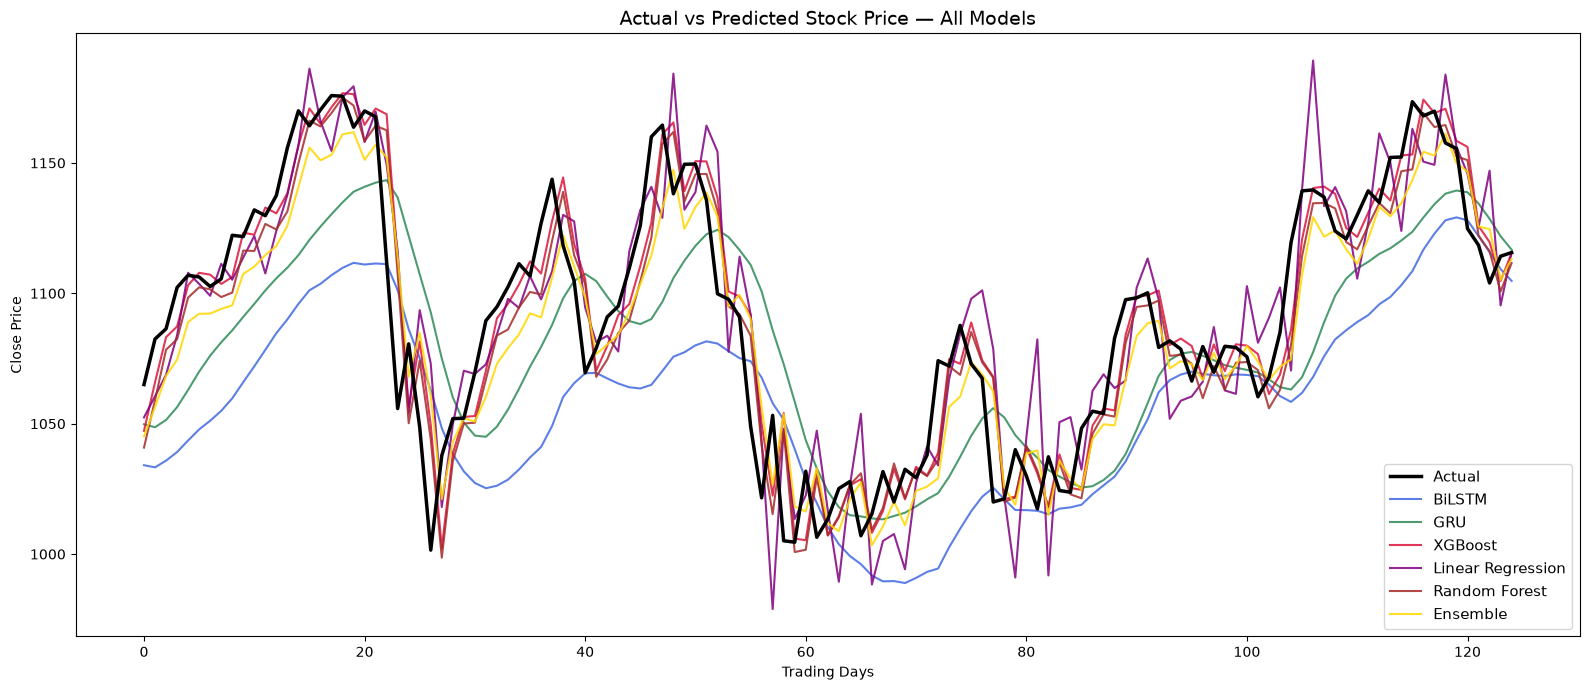

In [18]:
#17.  VISUALISATIONS
#VIZ-1
plt.figure(figsize=(16, 7))
plt.plot(real_close, label='Actual', color='black',
         linewidth=2.5, zorder=5)
for name, pred in preds.items():
    plt.plot(pred, label=name, alpha=0.85,
             color=MODEL_COLORS[name], linewidth=1.5)
plt.xlabel('Trading Days')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Stock Price — All Models', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("plots/02_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

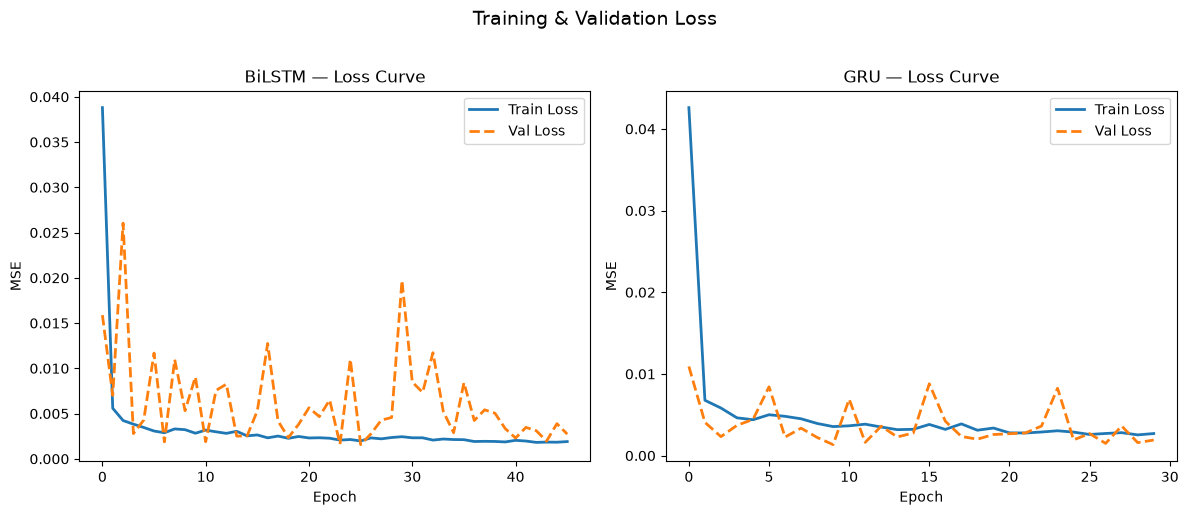

In [19]:
#VIZ-2
histories = {
    'BiLSTM':   history_bilstm,
    'GRU':      history_gru
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'],     label='Train Loss', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=2,
            linestyle='--')
    ax.set_title(f'{name} — Loss Curve', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.suptitle('Training & Validation Loss', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/03_loss_curves.png", dpi=300, bbox_inches='tight')
plt.show()

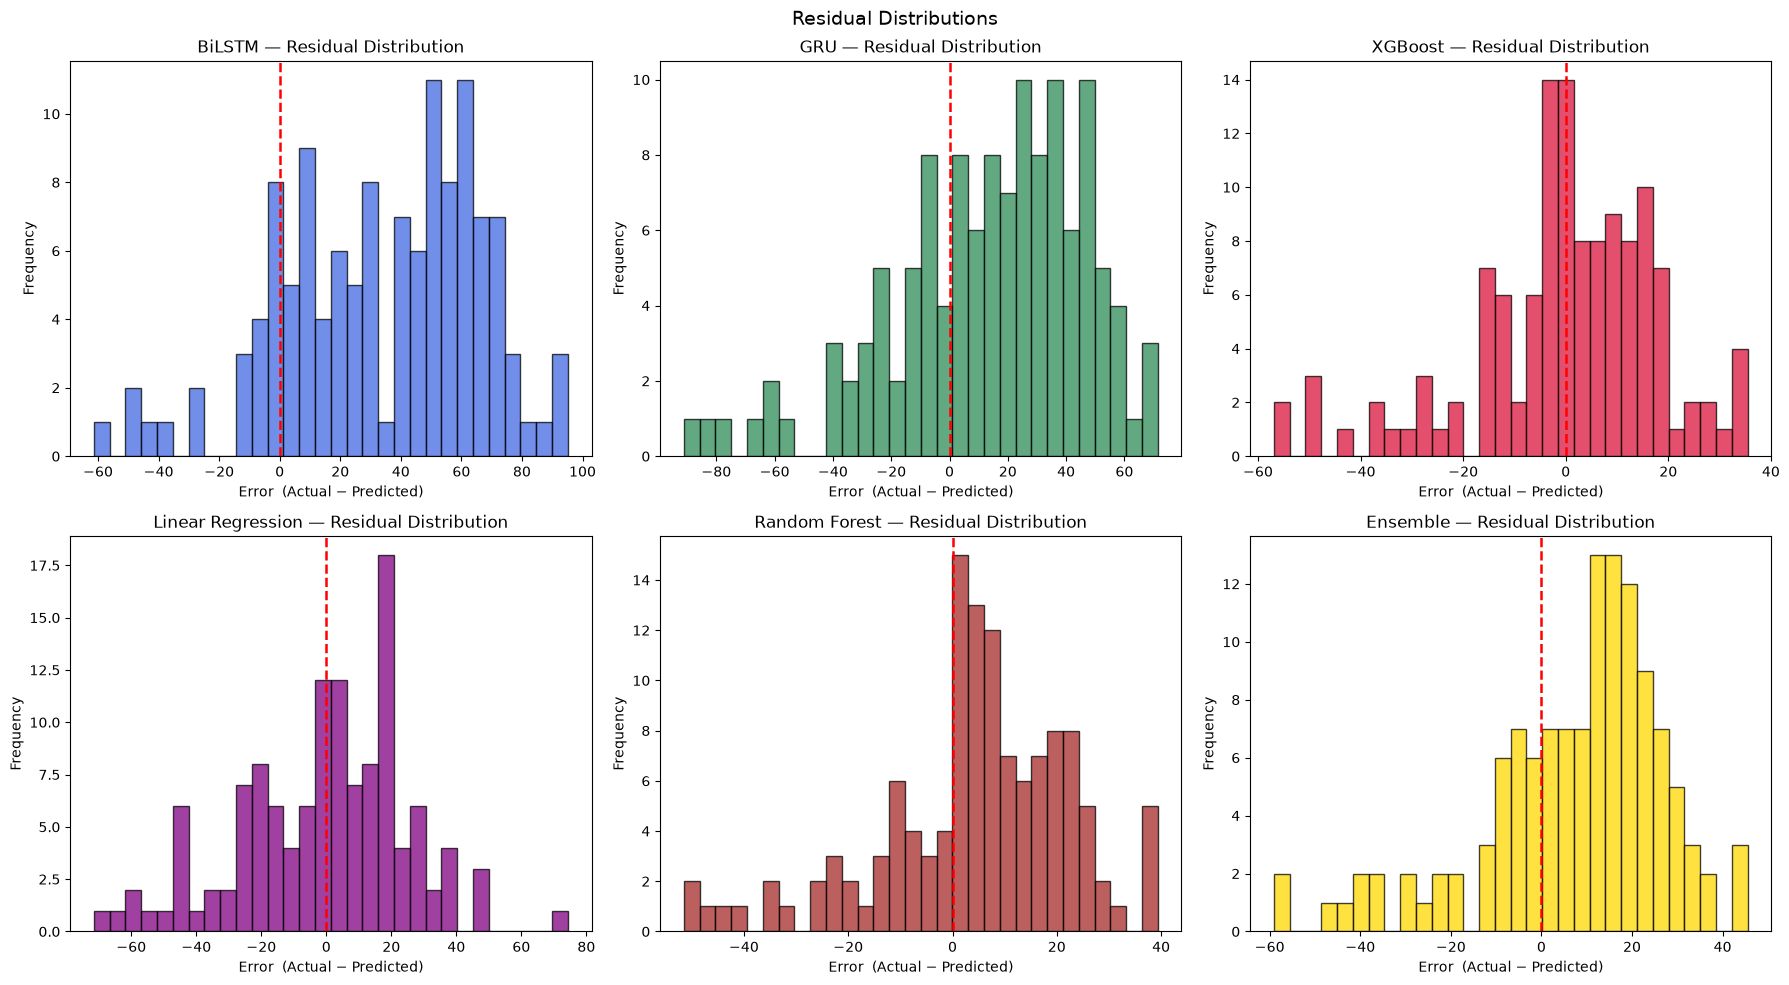

In [20]:
#VIZ-3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (name, pred) in zip(axes, preds.items()):
    residuals = real_close - pred
    ax.hist(residuals, bins=30, color=MODEL_COLORS[name],
            edgecolor='black', alpha=0.75)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.8)
    ax.set_title(f'{name} — Residual Distribution', fontsize=12)
    ax.set_xlabel('Error  (Actual − Predicted)')
    ax.set_ylabel('Frequency')
plt.suptitle('Residual Distributions', fontsize=14)
plt.tight_layout()
plt.savefig("plots/04_residual_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

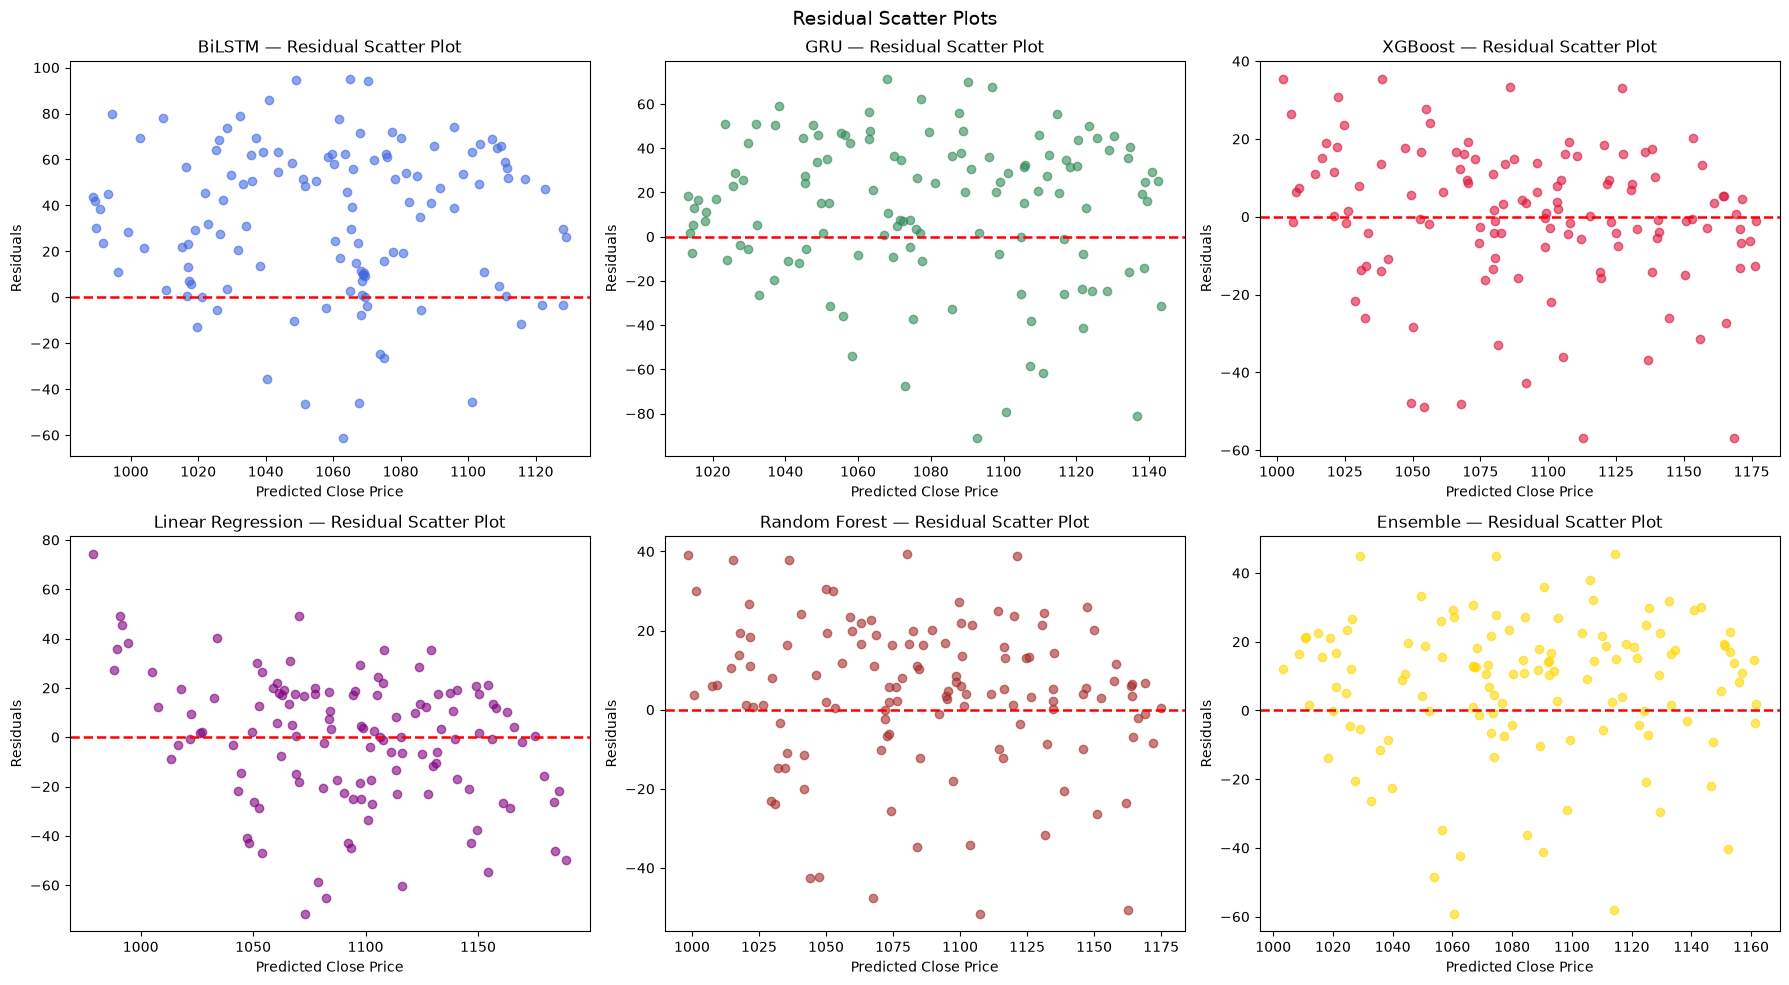

In [21]:
#VIZ-4
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, preds.items()):
    residuals = real_close - pred

    ax.scatter(pred, residuals,
               color=MODEL_COLORS[name],
               alpha=0.6)

    ax.axhline(y=0, color='red',
               linestyle='--',
               linewidth=1.8)

    ax.set_title(f'{name} — Residual Scatter Plot', fontsize=12)
    ax.set_xlabel('Predicted Close Price')
    ax.set_ylabel('Residuals')

plt.suptitle('Residual Scatter Plots', fontsize=14)
plt.tight_layout()
plt.savefig("plots/05_residual_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

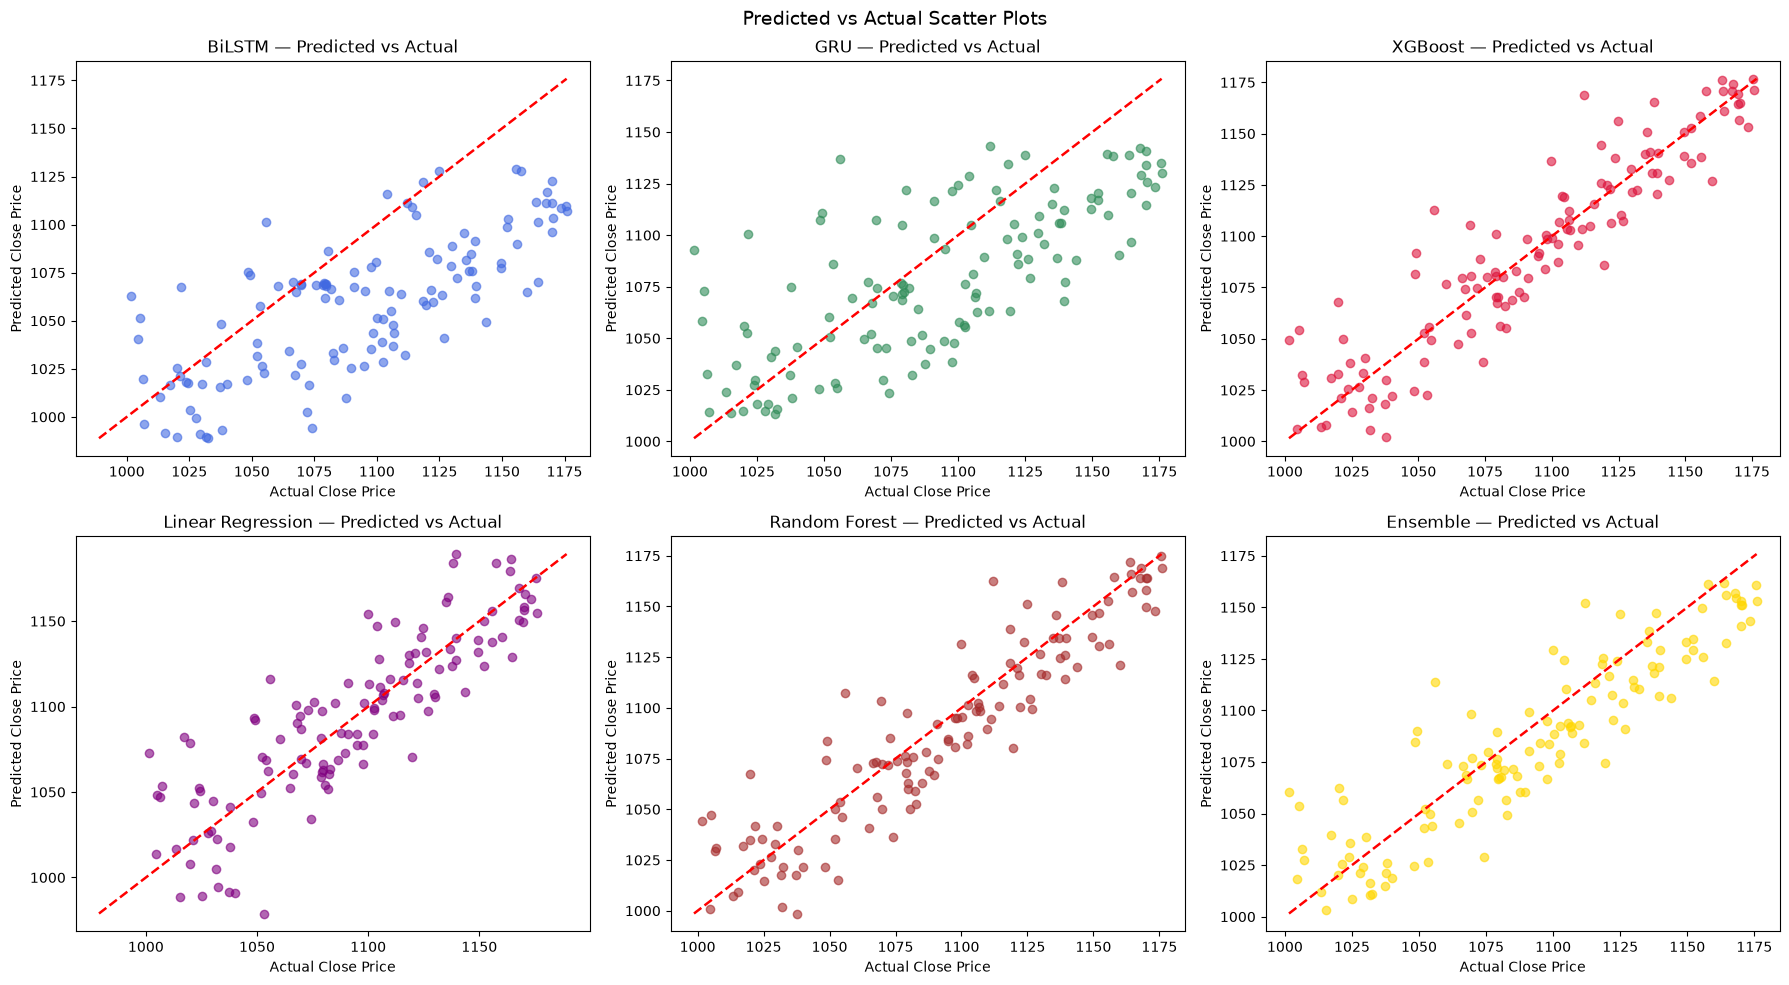

In [22]:
#VIZ-5
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, preds.items()):

    # Scatter plot
    ax.scatter(
        real_close,
        pred,
        color=MODEL_COLORS[name],
        alpha=0.6
    )

    # Perfect prediction line
    min_val = min(real_close.min(), pred.min())
    max_val = max(real_close.max(), pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.8
    )

    ax.set_title(f'{name} — Predicted vs Actual', fontsize=12)
    ax.set_xlabel('Actual Close Price')
    ax.set_ylabel('Predicted Close Price')

plt.suptitle('Predicted vs Actual Scatter Plots', fontsize=14)
plt.tight_layout()
plt.savefig("plots/06_predicted_vs_actual_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

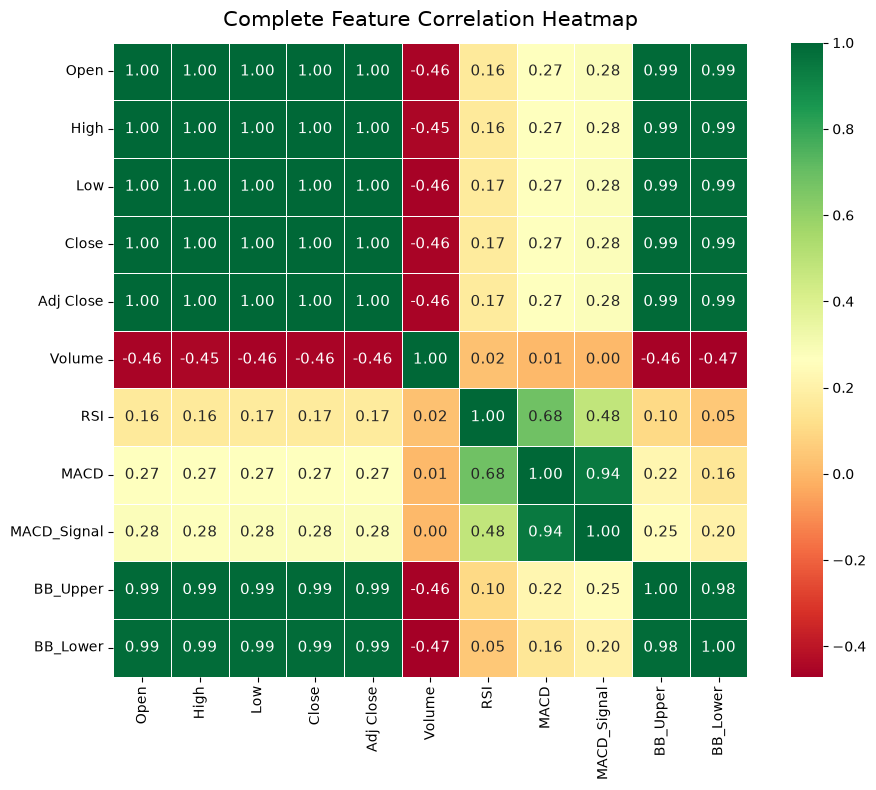

In [23]:
#VIZ-6
plt.figure(figsize=(10, 8))
sns.heatmap(
    train_data[FEATURES].corr(), annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5, square=True,
    annot_kws={'size': 11}
)
plt.title('Complete Feature Correlation Heatmap', fontsize=15, pad=12)
plt.tight_layout()
plt.savefig("plots/07_correlation_heatmap_full.png", dpi=300, bbox_inches='tight')
plt.show()

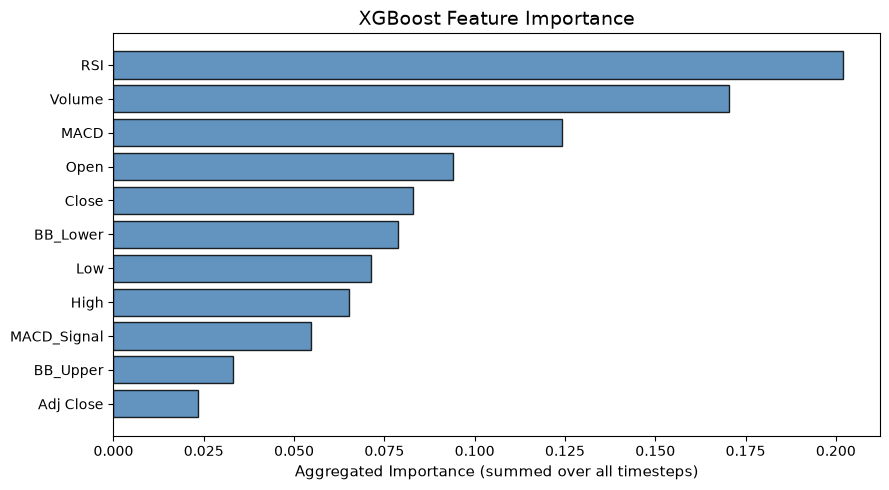

In [24]:
#VIZ-7
importances     = model_xgb.feature_importances_   # length = SEQ_LEN * N_FEAT
feat_imp_agg    = np.zeros(N_FEAT)
for idx, imp in enumerate(importances):
    feat_imp_agg[idx % N_FEAT] += imp

sorted_idx = np.argsort(feat_imp_agg)
plt.figure(figsize=(9, 5))
bars = plt.barh(
    [FEATURES[i] for i in sorted_idx],
    feat_imp_agg[sorted_idx],
    color='steelblue', edgecolor='black', alpha=0.85
)
plt.xlabel('Aggregated Importance (summed over all timesteps)', fontsize=11)
plt.title('XGBoost Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig("plots/08_xgb_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()


Generating SHAP explanations...


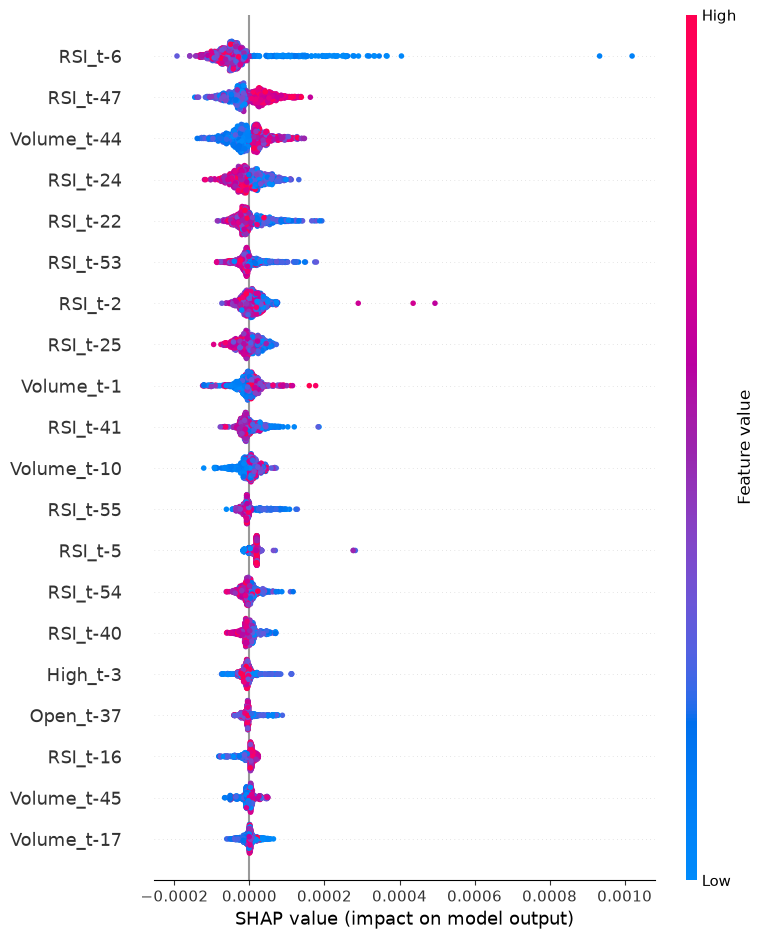

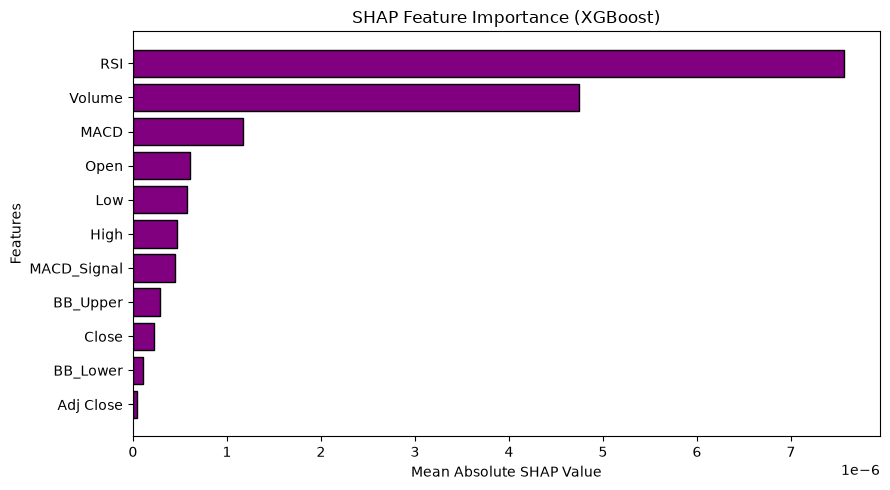

In [25]:
#VIZ-8
print("\nGenerating SHAP explanations...")

# Use a subset for speed
sample_size = min(1000, len(X_train_flat))
X_shap = X_train_flat[:sample_size]

shap_feature_names = [
    f"{FEATURES[f]}_t-{SEQ_LEN - t}"
    for t in range(SEQ_LEN)
    for f in range(N_FEAT)
]

# Create explainer
explainer = shap.TreeExplainer(model_xgb)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=shap_feature_names,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig("plots/09_shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# Aggregate importance across all timesteps
shap_agg = np.zeros(N_FEAT)

for feature_idx in range(N_FEAT):
    cols = np.arange(feature_idx, X_shap.shape[1], N_FEAT)
    shap_agg[feature_idx] = np.mean(np.abs(shap_values[:, cols]))

sorted_idx = np.argsort(shap_agg)

# Plot
plt.figure(figsize=(9,5))

plt.barh(
    [FEATURES[i] for i in sorted_idx],
    shap_agg[sorted_idx],
    color='purple',
    edgecolor='black'
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Features")
plt.title("SHAP Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig("plots/10_shap_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

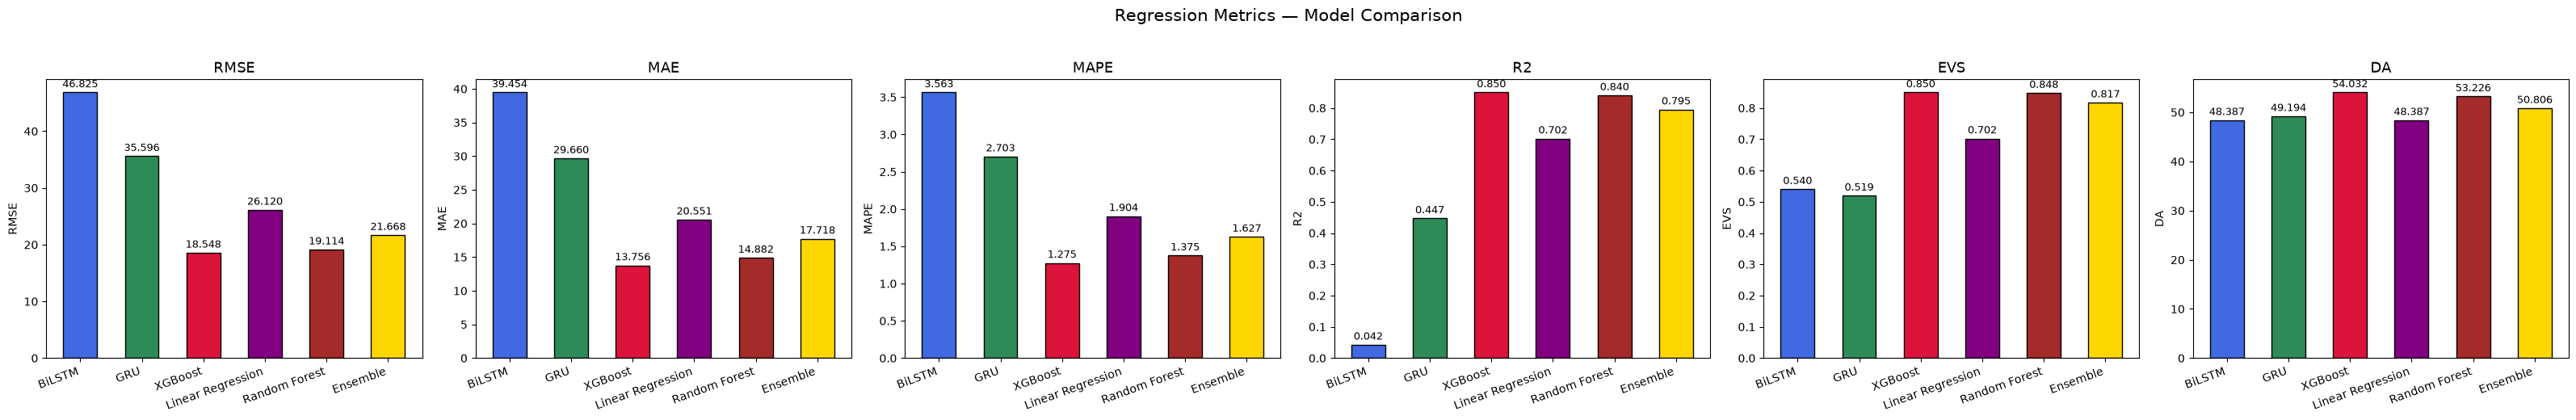

In [26]:
#VIZ-9
reg_df = pd.DataFrame(reg_results).T
colors = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 6, figsize=(32, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE', 'R2', 'EVS', 'DA']):
    bars = ax.bar(reg_df.index, reg_df[metric],
                  color=colors, edgecolor='black', width=0.55)
    ax.set_title(f'{metric}', fontsize=13)
    ax.set_ylabel(metric)
    ax.set_xticklabels(reg_df.index, rotation=20, ha='right')
    for bar, val in zip(bars, reg_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Regression Metrics — Model Comparison', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig("plots/11_regression_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# 18.  SAVE ALL MODELS
model_bilstm.save("model_bilstm.keras")
model_gru.save("model_gru.keras")
model_xgb.save_model("model_xgb.json")
joblib.dump(model_lr, "model_linear_regression.pkl")
joblib.dump(model_rf, "model_random_forest.pkl")

print("\n" + "="*50)
print("  All models saved successfully!")
print("    model_bilstm.keras")
print("    model_gru.keras")
print("    model_xgb.json")
print("    model_linear_regression.pkl")
print("    model_random_forest.pkl")
print("="*50)


  All models saved successfully!
    model_bilstm.keras
    model_gru.keras
    model_xgb.json
    model_linear_regression.pkl
    model_random_forest.pkl
